# A project about data analysis
## 采集数据->分析方向确定->导入->清洗数据->分析数据->数据可视化
## 数据源介绍：
字段名:city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url

分析及统计问题:最影响房价的变量？全国房价总体分布？不同城市房价水平？高价房在面积、楼层方面的特征？那种户型最受欢迎？
朝向是否影响价格？……

## 1.导入库

In [2]:
# 导入库
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei']


## 2.导入数据文件

In [3]:
# 导入文件
df = pd.read_csv('property.csv')
print(len(df))

352


In [4]:
# 数据概览
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352 entries, 0 to 351
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   city        348 non-null    object 
 1   address     350 non-null    object 
 2   area        349 non-null    float64
 3   floor       348 non-null    float64
 4   name        346 non-null    object 
 5   price       350 non-null    float64
 6   province    351 non-null    object 
 7   rooms       351 non-null    object 
 8   toward      351 non-null    object 
 9   unit        352 non-null    object 
 10  year        330 non-null    float64
 11  origin_url  351 non-null    object 
dtypes: float64(4), object(8)
memory usage: 33.1+ KB


## 3.数据清洗

In [5]:
# 数据清洗
# url是无用列，可删除
df.drop(columns = 'origin_url', inplace = True)
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,北京,朝阳区望京街10号院,88.0,9.0,望京花园,620.0,北京市,2室1厅,南,2单元,2015.0
1,上海,浦东新区锦绣路300弄,1200.0,13.0,锦绣华庭,980.0,上海市,3室2厅,南北,5单元,2018.0
2,广州,天河区珠江新城花城大道66号,95.0,5.0,凯旋新世界,750.0,广东省,2室2厅,东南,3单元,2020.0
3,深圳,南山区科技园科发路8号,150.0,23.0,科技园壹号,1650.0,广东省,4室2厅,南,1单元,2021.0
4,杭州,西湖区文一路123号,85.0,7.0,文欣苑,480.0,浙江省,2室2厅,南,2单元,2010.0


In [6]:
# 处理缺失值
df.isna().sum()
df.dropna(inplace = True)

In [7]:
# 处理重复值
df.duplicated().sum()
# 删除重复数据
df.drop_duplicates(inplace = True)

In [8]:
print(len(df))
df.duplicated().sum()

271


np.int64(0)

In [9]:
# 单元数据类型转换
df['unit'] = df['unit'].str.replace('单元', '').astype(int) # 将单位(单元)替换为空

In [10]:
# 朝向数据类型转换
df['toward'] = df['toward'].astype('category')

In [11]:
df['year'] = df['year'].astype(int)
df['floor'] = df['floor'].astype(int)

In [12]:
# 异常值处理
# 房屋面积
df = df[ (df['area'] < 600) & (df['area'] > 20) ]

In [13]:
# 房屋总价
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[ (df['price']>lower_bound) & (df['price']<upper_bound) ] # 用IQR方法保留价格正常的数据

## 4.新数据特征构造

In [14]:
# 楼层类型:floor_type
df['floor_type'] = df['floor'].apply(lambda x: '低' if x <= 3 else ('中' if x <= 6 else '高')).astype('category')
# 是否直辖市:municipality
df['municipality'] = df['city'].apply(lambda x: True if x in ['北京', '上海', '重庆', '天津'] else False).astype('category')
# 卧室数量:bedrooms
df['bedrooms'] = df['rooms'].str.split('室').str[0].astype(int)
# 客厅数量:halls
# df['halls'] = df['rooms'].str.split('室').str[1].str.split('厅').str[0].astype(int) 
df['halls'] = df['rooms'].str.extract(r'(\d+)厅').astype(int) # 正则表达式
# 房龄:age
df['age'] = 2026 - df['year']
# 价格分段:price_labels
df['price_labels'] = pd.cut(df['price'], bins = 4, labels = ['低价', '中价', '高价', '超高价'])
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,floor_type,municipality,bedrooms,halls,age,price_labels
0,北京,朝阳区望京街10号院,88.0,9,望京花园,620.0,北京市,2室1厅,南,2,2015,高,True,2,1,11,高价
2,广州,天河区珠江新城花城大道66号,95.0,5,凯旋新世界,750.0,广东省,2室2厅,东南,3,2020,中,False,2,2,6,超高价
4,杭州,西湖区文一路123号,85.0,7,文欣苑,480.0,浙江省,2室2厅,南,2,2010,高,False,2,2,16,高价
5,南京,建邺区奥体大街69号,110.0,6,奥体新城,520.0,江苏省,3室2厅,南北,3,2016,中,False,3,2,10,高价
6,成都,高新区天府大道中段500号,98.0,17,天府世家,280.0,四川省,3室1厅,东,1,2017,高,False,3,1,9,中价


## 5.数据分析与可视化

e:\Anaconda\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.draw()
e:\Anaconda\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  func(*args, **kwargs)
e:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


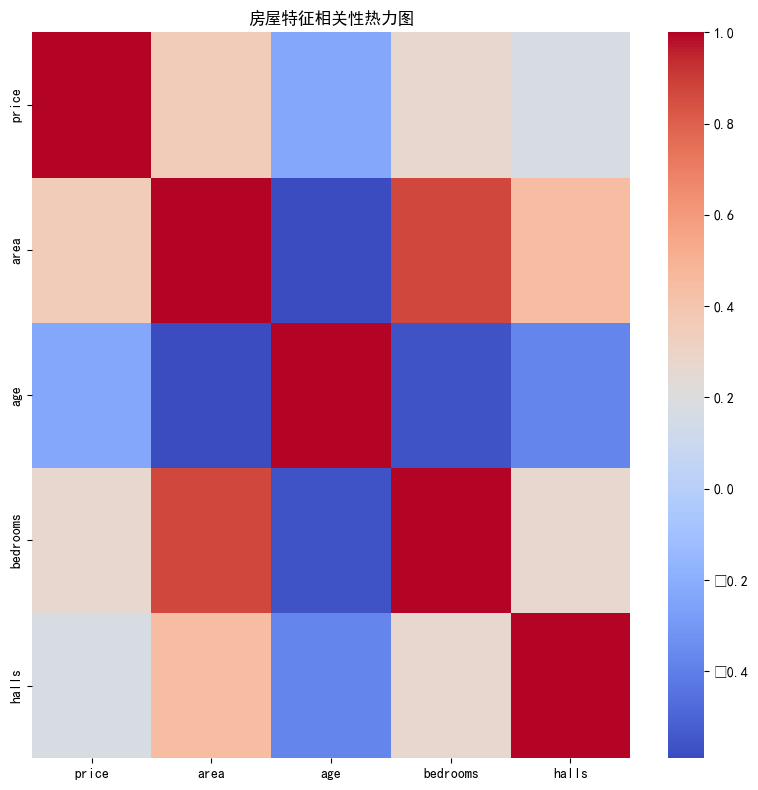

In [33]:
# 计算相关度(哪些变量最影响房价？面积，楼层，房间数哪个影响更大？)
# 指标/方法:皮尔逊相关系数
# 选择数值型特征
a = df[['price', 'area', 'age', 'bedrooms', 'halls']].corr() # 计算相关系数
# 取相关系数最高的变量
a['price'].sort_values(ascending = False)[1:]
# 相关性热力图
plt.figure(figsize = (8,8))
sns.heatmap(a,cmap = 'coolwarm')
plt.title('房屋特征相关性热力图')
plt.tight_layout()

In [34]:
# 全国房价总体分布
df.describe()

,area,floor,price,unit,year,bedrooms,halls,age
count,246.000000,246.000000,246.000000,246.000000,246.000000,246.000000,246.000000,246.000000
mean,108.597561,14.008130,320.191057,2.093496,2014.337398,2.695122,1.800813,11.662602
std,21.004097,5.969987,181.291647,0.991494,3.005434,0.613235,0.400203,3.005434
min,68.000000,2.000000,62.000000,1.000000,2003.000000,1.000000,1.000000,6.000000
25%,93.500000,9.000000,180.000000,1.000000,2013.000000,2.000000,2.000000,10.000000
50%,105.000000,13.500000,270.000000,2.000000,2015.000000,3.000000,2.000000,11.000000
75%,119.500000,18.000000,450.000000,3.000000,2016.000000,3.000000,2.000000,13.000000
max,210.000000,31.000000,890.000000,5.000000,2020.000000,5.000000,2.000000,23.000000


(array([29., 71., 49., 23., 20., 21., 19.,  9.,  2.,  3.]),
 array([ 62. , 144.8, 227.6, 310.4, 393.2, 476. , 558.8, 641.6, 724.4,
        807.2, 890. ]),
 <BarContainer object of 10 artists>)

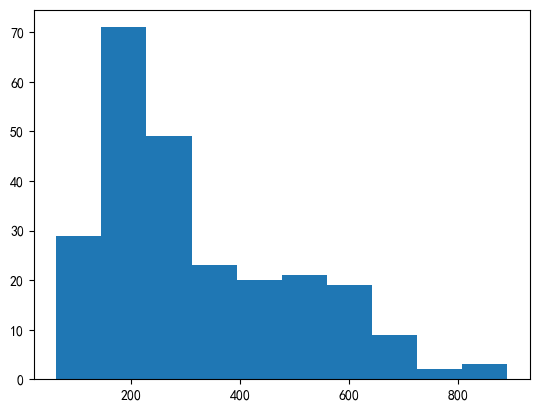

In [35]:
# 房价分布直方图
plt.subplot(111)
plt.hist(df['price'], bins = 10)

<Axes: xlabel='price', ylabel='Count'>

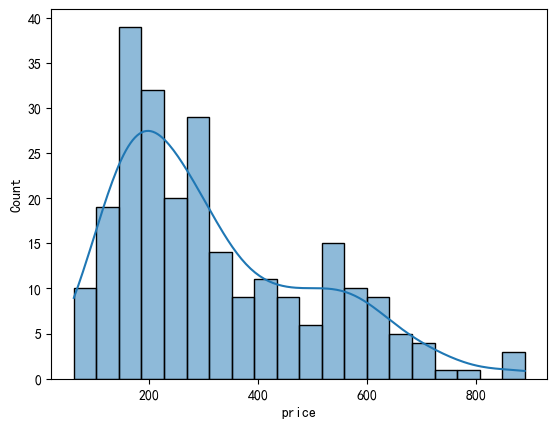

In [36]:
sns.histplot(data = df, x = 'price',bins = 20, kde = True)

In [39]:
# 评估不同朝向对价格的影响
df['toward'].value_counts()
df.groupby('toward').agg({
    'price' : ['mean', 'median'],
    'age' : 'mean'
})

C:\Users\dell\AppData\Local\Temp\ipykernel_22340\100810465.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('toward').agg({


price               age
              mean median       mean
toward                              
东       259.451613  235.0  13.967742
东南      370.666667  340.0  10.814815
东西      165.000000  165.0  14.000000
北       253.793103  190.0  13.655172
南       360.475000  315.0  11.025000
南北      350.000000  285.0  10.084746
西       190.722222  147.5  13.666667
西北      270.000000  270.0  11.000000

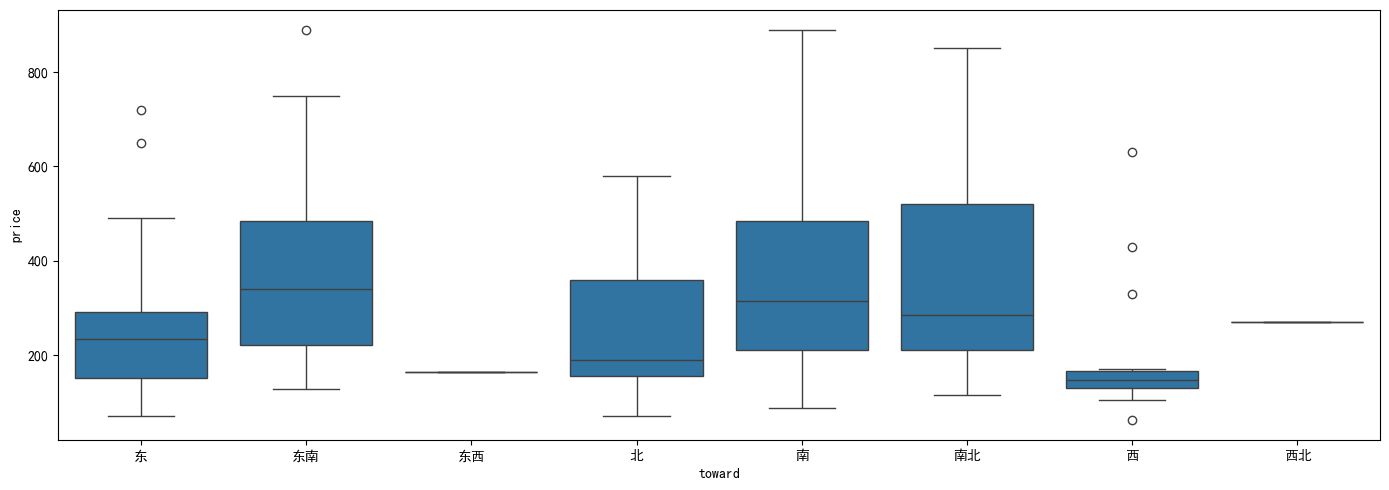

In [40]:
plt.figure(figsize=(14,5))
sns.boxplot(x = 'toward', y = 'price', data = df)
plt.tight_layout()